# Ingredient Confidence Analysis by Country

The focus of this analysis lies on the OpenFoodFacts products which have associated ingredient images.

Data used: jsonl.gz dataset (from March 17 2025).

Steps:
1. map country names to country codes
2. categorize product by age of last uploaded ingredient image
3. categorize product by ratio of identified ingredients

## Download jsonl.gz snapshot

This will take a couple of minutes

In [1]:
%%time
%%bash
if [ ! -f "openfoodfacts-products.jsonl.gz" ]; then
    curl -L -O https://static.openfoodfacts.org/data/openfoodfacts-products.jsonl.gz;
else
    echo "file already exists. skipping download";
fi

file already exists. skipping download
CPU times: user 3.22 ms, sys: 7.68 ms, total: 10.9 ms
Wall time: 10.3 ms


## Data Extraction - DuckDB

Duckdb is faster than `jq`. The result of this SQL query is equivalent to the `jq` output (except for some unexpected characters).

```sql
COPY (
  WITH data AS (
    SELECT *
    FROM read_ndjson(
      'openfoodfacts-products.jsonl.gz', ignore_errors=True,
      columns={
        code:'VARCHAR',
        countries_tags: 'VARCHAR[]',
        known_ingredients_n:'INTEGER',
        unknown_ingredients_n:'INTEGER',
        ingredients_percent_analysis:'INTEGER',
        images:'MAP(VARCHAR, STRUCT(imgid INTEGER, uploader VARCHAR, uploaded_t INTEGER))',
        states_tags:'VARCHAR[]',
        data_quality_info_tags:'VARCHAR[]'
      }
    )
  )
  SELECT
    code,
    array_to_string(countries_tags, ',') AS countries_tags,
    known_ingredients_n,
    unknown_ingredients_n,
    ingredients_percent_analysis,
    (
      SELECT
        -- duckdb cannot handle nested JSON with variables (yet) - need to build the string manually
        '{' || string_agg(
          '"' || t.imgkey || '":' ||
            json_object(
              'imgid', t.imgid::INTEGER,
              'uploader', t.uploader,
              'uploaded_t', t.uploaded_t::INTEGER
            ),
          ','
        ) || '}'
      FROM (
        -- Lateral unnest: for each row from data, unnest matching keys (if any)
        SELECT
          k AS imgkey,
          images->k->>'imgid' AS imgid,
          images->(images->k->>'imgid')->>'uploader' AS uploader,
          images->(images->k->>'imgid')->>'uploaded_t' AS uploaded_t
        FROM UNNEST(list_filter(map_keys(images), x -> x LIKE 'ing%')) AS t(k)
      ) t
    ) AS images,
    array_to_string(list_filter(states_tags, x -> x LIKE 'en:ing%'), ',') as states,
    array_to_string(list_filter(data_quality_info_tags, x -> x LIKE 'en:ing%'), ',') as quality_info
  FROM data
) TO 'ingredients_data_country_dd.csv.gz' (FORMAT CSV, HEADER, FORCE_QUOTE (code, countries_tags, images, states, quality_info));
```

## Data Loading

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
file_path = "../data/ingredients_data_country_dd.csv.gz"
df = pd.read_csv(file_path, dtype={'code':str})
df = df[df.code.notna()].set_index('code') # exclude empty barcodes

# use Int64 for counts with NaN
for col in ['known_ingredients_n', 'unknown_ingredients_n', 'ingredients_percent_analysis']:
    df[col] = df[col].astype('Int64')

# convert json string to dict
df.images = df.images.fillna('null').map(json.loads)

# convert countries tags list
df.countries_tags = df.countries_tags.str.split(',')

display(df)

,countries_tags,known_ingredients_n,unknown_ingredients_n,ingredients_percent_analysis,images,states,quality_info
code,,,,,,,
0000101209159,[en:france],<NA>,<NA>,<NA>,"{'ingredients_fr': {'imgid': 2, 'uploader': 'k...","en:ingredients-to-be-completed,en:ingredients-...",NaN
0000105000011,[en:united-states],3,0,1,None,en:ingredients-completed,en:ingredients-percent-analysis-ok
0000105000042,[en:united-states],3,0,1,None,en:ingredients-completed,en:ingredients-percent-analysis-ok
0000105000059,[en:united-states],0,1,1,None,en:ingredients-completed,en:ingredients-percent-analysis-ok
0000105000073,[en:united-states],2,0,1,None,en:ingredients-completed,en:ingredients-percent-analysis-ok
...,...,...,...,...,...,...,...
8718907242424,[en:netherlands],<NA>,<NA>,<NA>,None,en:ingredients-to-be-completed,NaN
0007405956277,[en:belgium],<NA>,<NA>,<NA>,None,"en:ingredients-to-be-completed,en:ingredients-...",NaN
3760019590615,[en:france],<NA>,<NA>,<NA>,None,"en:ingredients-to-be-completed,en:ingredients-...",NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3753725 entries, 0000101209159 to 3111902100273
Data columns (total 7 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   countries_tags                object
 1   known_ingredients_n           Int64 
 2   unknown_ingredients_n         Int64 
 3   ingredients_percent_analysis  Int64 
 4   images                        object
 5   states                        object
 6   quality_info                  object
dtypes: Int64(3), object(4)
memory usage: 239.8+ MB


In [5]:
df.countries_tags.explode().value_counts()

countries_tags
en:france                     1118498
en:united-states               737884
en:spain                       334958
en:germany                     324920
en:italy                       251778
                               ...   
en:كندا                             1
en:svalbard-and-jan-mayen           1
fr:europa                           1
ar:الدمام                           1
en:british-columbia-canada          1
Name: count, Length: 480, dtype: int64

In [6]:
df.countries_tags[lambda x: x.notna()].map(len).value_counts().sort_index()

countries_tags
1     3531589
2      173408
3       17316
4        3755
5        1451
6         651
7         387
8         319
9         129
10        101
11         84
12         62
13         35
14         37
15         23
16         17
17         14
18         10
19          7
20          4
21          2
22          2
23          4
24          2
25          2
26          3
27          3
28          3
29          2
31          2
36          1
37          1
Name: count, dtype: int64

## Map Country Names to Country Codes

In [7]:
file_path = "../data/country_tag_mapping.csv"
df_cc = pd.read_csv(file_path).set_index("country_tag")
df_cc

,code,flag
country_tag,,
en:france,FR,🇫🇷
en:united-states,US,🇺🇸
en:spain,ES,🇪🇸
en:germany,DE,🇩🇪
en:italy,IT,🇮🇹
...,...,...
en:malaysia-english,MY,🇲🇾
en:nicaragua-espanol,NI,🇳🇮
en:panama-espanol,PA,🇵🇦


In [8]:
code_lookup = df_cc['code'].to_dict()

# Apply a function only where needed
df['cc'] = df['countries_tags'].apply(
    lambda tags: [code_lookup[tag] for tag in tags if tag in code_lookup] if isinstance(tags, list) else None
)
df.cc

code
0000101209159    [FR]
0000105000011    [US]
0000105000042    [US]
0000105000059    [US]
0000105000073    [US]
                 ... 
8718907242424    [NL]
0007405956277    [BE]
3760019590615    [FR]
8718452581313    [NL]
3111902100273    [FR]
Name: cc, Length: 3753725, dtype: object

In [9]:
df.cc.explode().value_counts()

cc
FR    1119840
US     738222
ES     335061
DE     326083
IT     251786
       ...   
SB          3
AQ          3
MH          2
ST          2
TO          2
Name: count, Length: 189, dtype: int64

### Apply Confidence Criteria: Last Upload of an Ingredient Image

In [10]:
def last_image_upload(info: dict) -> pd.Timestamp:
  if isinstance(info, dict):
    # note: timestamp may be None, list may be empty after filtering
    ts_list = [v['uploaded_t'] for v in info.values() if v['uploaded_t'] is not None]
    last = max(ts_list) if ts_list else None
    return pd.Timestamp(last, unit='s') if last else None
  else:
    return None

age_categories = ["<1 yr", "1-2 yrs", "2-5 yrs", "5-10 yrs", ">10 yrs"]
labels = ['Very Recent', 'Recent', 'Moderate Age', 'Old', 'Very Old']

def categorize_age(yrs: int) -> str:
  if pd.isna(yrs):
      return None

  if yrs == 0:
      return age_categories[0]
  elif yrs == 1:
      return age_categories[1]
  elif yrs < 5:
      return age_categories[2]
  elif yrs < 10:
      return age_categories[3]
  else:
      return age_categories[4]

last = df.images.apply(last_image_upload)
yrs = (pd.Timestamp.today() - last).dt.days.floordiv(365.25).astype("Int64")

df['image_age'] = yrs.apply(categorize_age)
df.image_age.value_counts(dropna=False)

image_age
None        2728538
5-10 yrs     535593
2-5 yrs      236172
1-2 yrs      123592
<1 yr        113759
>10 yrs       16071
Name: count, dtype: int64

In [11]:
cols = ['cc', 'image_age']
grouped = (
  df[cols]
  .explode('cc')
  .dropna(subset=['cc'])
  .groupby(cols)
  .size()
  .unstack()
  .fillna(0)
  .astype(int)
)

top_countries = grouped.sum(axis=1).nlargest(12).index

colors = ['green', 'lightgreen', 'orange', 'red', 'grey']
top = grouped.loc[top_countries].reindex(columns=age_categories)

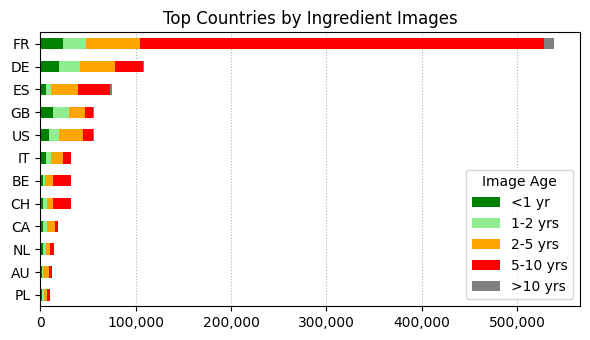

In [12]:
fig, ax = plt.subplots(figsize=(6, 3.5))

top.plot.barh(stacked=True, ax=ax, color=colors)
ax.invert_yaxis()
ax.set_ylabel(None)
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')

ax.set_axisbelow(True)
plt.grid(axis='x', linestyle=':', linewidth=0.8)
plt.legend(title="Image Age")
plt.title('Top Countries by Ingredient Images')
plt.tight_layout()
plt.show()